<a href="https://colab.research.google.com/github/naman065/Stochastic-Modelling-of-Financial-Derivatives/blob/main/SMFD_Assn5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMFD Assignment - 5
Naman Mohan Singh, Ashish Kumar Jha, Shubham Agarwal

##Simulation of Call Option Prices via Stochastic Differential Equations
### 📌 Objective

We estimate the fair price of a **European Call Option** using:

- **Euler–Maruyama method** to simulate the stock price path.
- **Monte Carlo averaging** to estimate the expected payoff.

---

#European Call Option

### 📌 Objective

We estimate the fair price of a **European Call Option** using:

- **Euler–Maruyama method** to simulate the stock price path.
- **Monte Carlo averaging** to estimate the expected payoff.

---

### ⚙️ Assumptions

1. **Underlying Asset Dynamics** follow **Geometric Brownian Motion (GBM)**:

   $$ dS(t) = r S(t)\,dt + \sigma S(t)\,dW(t) $$

   where:
   - $S(t)$: stock price at time $t$
   - $r$: risk-free interest rate
   - $\sigma$: volatility
   - $dW(t)$: Brownian motion increment (normally distributed)

2. We assume:
   - Constant $r$, $\sigma$
   - No dividends
   - No arbitrage, frictionless markets

3. **Euler–Maruyama Discretization**:

   $$ S_{t+\Delta t} = S_t + r S_t \Delta t + \sigma S_t \Delta W $$

   where $\Delta W \sim \mathcal{N}(0, \Delta t)$

4. **Monte Carlo Simulation**:
   - Simulate many price paths $S(t)$.
   - Compute the option payoff at $T$:  
     $$ \text{Payoff} = \max(S_T - K,\, 0) $$
   - Estimate the option price as:  
     $$ C \approx e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \text{Payoff}_i $$

---

### 🧮 Parameters Used

| Parameter         | Value     | Description                        |
|------------------:|:----------|:-----------------------------------|
| $S_0$             | 100       | Initial stock price                |
| $K$               | 105       | Strike price                       |
| $r$               | 0.05      | Risk-free interest rate (annual)   |
| $\sigma$          | 0.2       | Volatility (annual)                |
| $T$               | 1         | Time to maturity (1 year)          |
| $N_{\text{steps}}$| 252       | Time steps (daily)                 |
| $N_{\text{paths}}$| 100,000   | Simulated paths                    |

---

### 📊 Output

We simulate 100,000 paths using daily time steps and compute the average of the discounted terminal payoffs to estimate the option's price. We also plot a few sample paths of $S(t)$ to visualize the stochastic process.


Estimated European Call Option Price: 7.9670


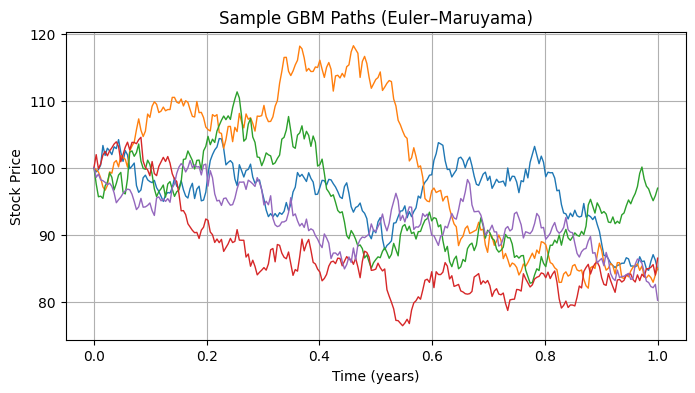

In [1]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Parameters for the European Call Option
S0 = 100       # Initial stock price
K = 105        # Strike price
r = 0.05       # Risk-free interest rate (5% per annum)
sigma = 0.2    # Volatility (20% per annum)
T = 1.0        # Time to maturity in years

# Euler–Maruyama discretization parameters
N_steps = 252   # Number of time steps (daily steps for 1 year)
dt = T / N_steps

# Monte Carlo parameters
N_paths = 100000  # Number of simulated paths

# Pre-allocate array to store terminal prices
S_T = np.zeros(N_paths)

# Simulate asset paths using Euler–Maruyama
for i in range(N_paths):
    S = S0
    for _ in range(N_steps):
        # Generate Gaussian increment
        dW = np.random.normal(0, np.sqrt(dt))
        # Euler–Maruyama update: dS = r*S*dt + sigma*S*dW
        S = S + r * S * dt + sigma * S * dW
    S_T[i] = S

# Compute payoffs for the European call: max(S_T - K, 0)
payoffs = np.maximum(S_T - K, 0)

# Discount payoffs to present value and take the average
C_estimate = np.exp(-r * T) * np.mean(payoffs)

# Display the estimated option price
print(f"Estimated European Call Option Price: {C_estimate:.4f}")

# Plot a few sample paths to visualize
plt.figure(figsize=(8, 4))
for i in range(5):
    # Re-simulate a few paths for plotting
    S = S0
    path = [S]
    for _ in range(N_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S = S + r * S * dt + sigma * S * dW
        path.append(S)
    plt.plot(np.linspace(0, T, N_steps + 1), path, lw=1)

plt.title("Sample GBM Paths (Euler–Maruyama)")
plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()


##Arithmetic Asian Option

## Q1(b) Arithmetic Asian Option Pricing

We modify only the **payoff function** compared to the European call.

### 💡 Key Difference:

- The **Arithmetic Asian Call Option** pays:
  
  $$
  \text{Payoff} = \max\left(\bar{S} - K,\; 0\right)
  $$

  where $$\ \bar{S} \$$ is the arithmetic average of the stock prices over the life of the option.

### 🧮 Simulation Changes:

- We simulate each GBM path just like in part (a), but store all intermediate prices.
- After reaching maturity, we compute the arithmetic mean of the full path.
- This mean is used in the payoff instead of the final stock price.

---

### 🧠 Intuition:

Asian options are **path-dependent** because their payoff depends on the average price—not just the terminal price. This reduces the effect of volatility and makes the option cheaper than a European option with the same strike and maturity.



Arithmetic Asian Call Option Price: 3.4960925373210108


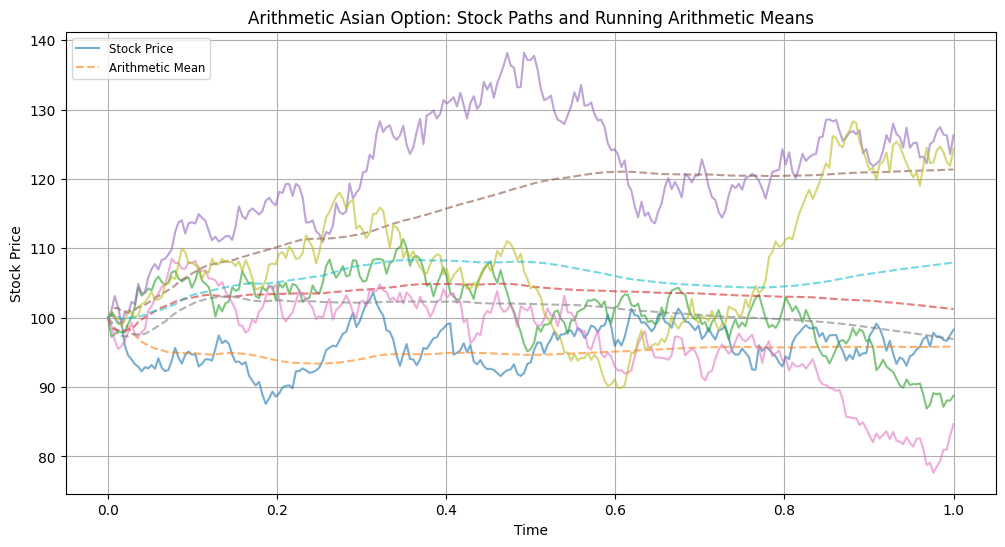

In [5]:
# Reduce number of paths to avoid timeout
N_paths = 10000  # 10,000 instead of 100,000 for speed

# Simulate paths using Euler–Maruyama
payoffs_asian_arithmetic = np.zeros(N_paths)
for i in range(N_paths):
    S = S0
    path = [S]
    for _ in range(N_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S = S + r * S * dt + sigma * S * dW
        path.append(S)
    average_price = np.mean(path)
    payoffs_asian_arithmetic[i] = max(average_price - K, 0)

# Discounted average payoff
asian_arithmetic_price = np.exp(-r * T) * np.mean(payoffs_asian_arithmetic)
print("Arithmetic Asian Call Option Price:", asian_arithmetic_price)
import matplotlib.pyplot as plt

# Simulate a few paths to visualize (e.g., 10 paths)
n_plot_paths = 5
paths = []
running_averages = []

for _ in range(n_plot_paths):
    S = S0
    path = [S]
    for _ in range(N_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S = S + r * S * dt + sigma * S * dW
        path.append(S)
    paths.append(path)
    running_averages.append(np.cumsum(path) / np.arange(1, len(path)+1))

# Plot
time_grid = np.linspace(0, T, N_steps + 1)
plt.figure(figsize=(12, 6))
for i in range(n_plot_paths):
    plt.plot(time_grid, paths[i], alpha=0.6)
    plt.plot(time_grid, running_averages[i], '--', alpha=0.6)

plt.title('Arithmetic Asian Option: Stock Paths and Running Arithmetic Means')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.grid(True)
plt.legend(['Stock Price', 'Arithmetic Mean'], loc='upper left', fontsize='small')
plt.show()



## Geometric Asian Option

## Q1(c) Geometric Asian Option Pricing

We now simulate the price of a **Geometric Asian Call Option** using Monte Carlo + Euler–Maruyama.

### 💡 Key Difference:

- The **Geometric Asian Call Option** pays:
  
  $$
  \text{Payoff} = \max\left(G - K,\; 0\right)
  $$

  where \( G \) is the **geometric mean** of the stock prices over time:

  $$
  G = \left(\prod_{i=0}^{n} S_i\right)^{\frac{1}{n+1}}
  $$

- This option is **less sensitive to extreme prices** than arithmetic average, so it is usually **cheaper**.

---

### 🧮 Simulation Overview:

- Use the same GBM simulation as in part (a), but compute the **geometric mean** of each path.
- Then use that mean in the payoff:
  
  $$
  \max(G - K, 0)
  $$

- Average the discounted payoffs over all Monte Carlo paths to estimate the option price.

---

### 🧠 Why It Matters:

Geometric Asian options are useful in theoretical models because they have **closed-form solutions** under GBM (unlike arithmetic Asian options). But here, we stick with the simulation-based approach.



Geometric Asian Call Option Price: 3.242963259032013


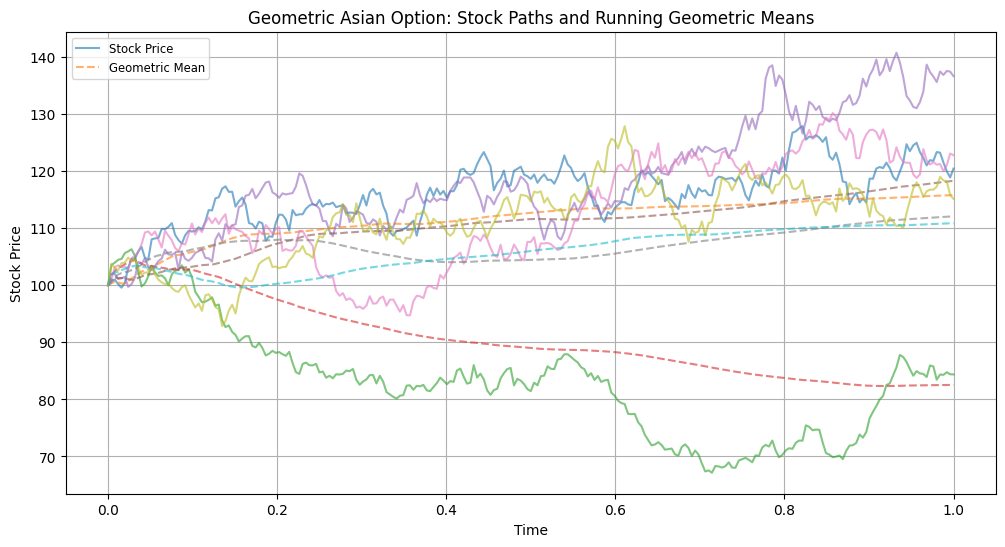

In [6]:
import numpy as np

# Parameters (same as before)
np.random.seed(42)
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 1.0
N_steps = 252
dt = T / N_steps
N_paths = 10000  # adjust as needed

# Simulate paths using Euler–Maruyama
payoffs_asian_geometric = np.zeros(N_paths)
for i in range(N_paths):
    S = S0
    path = [S]
    for _ in range(N_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S = S + r * S * dt + sigma * S * dW
        path.append(S)

    # Compute geometric average
    log_path = np.log(path)
    geometric_mean = np.exp(np.mean(log_path))

    # Payoff of Geometric Asian Call
    payoffs_asian_geometric[i] = max(geometric_mean - K, 0)

# Discounted Monte Carlo average
asian_geometric_price = np.exp(-r * T) * np.mean(payoffs_asian_geometric)
print("Geometric Asian Call Option Price:", asian_geometric_price)

# Simulate a few paths to visualize (e.g., 10 paths)
paths_geo = []
running_geom_averages = []

for _ in range(n_plot_paths):
    S = S0
    path = [S]
    for _ in range(N_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S = S + r * S * dt + sigma * S * dW
        path.append(S)
    paths_geo.append(path)

    # Running geometric mean
    log_path = np.log(path)
    log_cumsum = np.cumsum(log_path)
    running_geom = np.exp(log_cumsum / np.arange(1, len(log_path)+1))
    running_geom_averages.append(running_geom)

# Plot
plt.figure(figsize=(12, 6))
for i in range(n_plot_paths):
    plt.plot(time_grid, paths_geo[i], alpha=0.6)
    plt.plot(time_grid, running_geom_averages[i], '--', alpha=0.6)

plt.title('Geometric Asian Option: Stock Paths and Running Geometric Means')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.grid(True)
plt.legend(['Stock Price', 'Geometric Mean'], loc='upper left', fontsize='small')
plt.show()



## Lookback Call Option (Floating Strike)

## Q1(d) Lookback Call Option (Floating Strike)

### 🔍 Definition

A **Lookback Call Option with floating strike** gives the right to buy the asset at its lowest observed price over the option's life and sell it at the final market price.

### 💡 Payoff

$$
\text{Payoff} = \max(S_T - \min(S),\ 0)
$$

- $S_T$: terminal stock price
- $\min(S)$: lowest price during the life of the option

This option is highly valuable in volatile markets since the holder can always "look back" and choose the best (lowest) entry point.

---

### 🧮 Implementation Notes

- Simulate each GBM path (same as before).
- Track the **minimum price** along the path.
- Compute the payoff as the difference between final price and minimum.
- Average the discounted payoffs over all paths.


Lookback Call Option Price (Floating Strike): 16.509132772440896


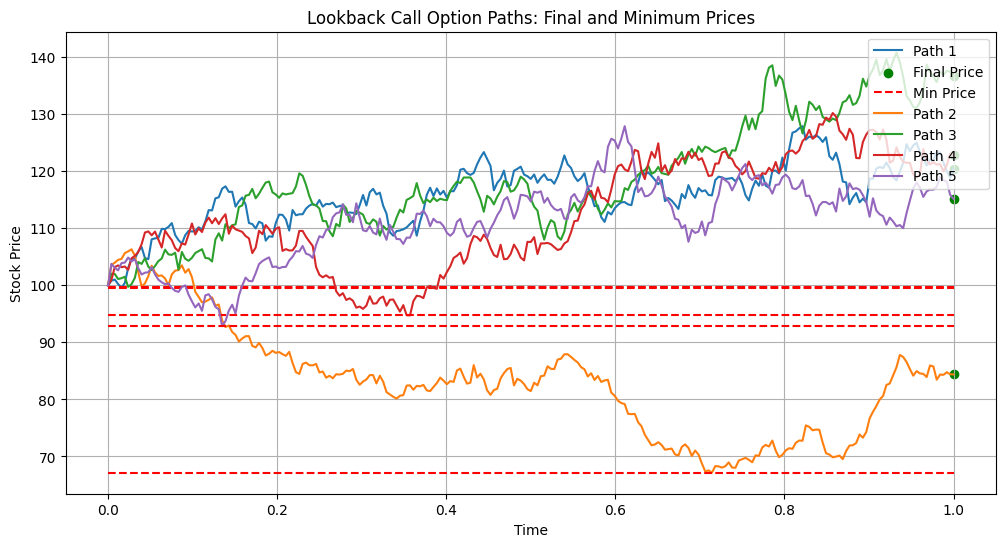

In [7]:
import numpy as np

# Parameters (reuse previous)
np.random.seed(42)
S0 = 100
r = 0.05
sigma = 0.2
T = 1.0
N_steps = 252
dt = T / N_steps
N_paths = 10000

# Lookback Call Option Payoff Simulation
payoffs_lookback = np.zeros(N_paths)

for i in range(N_paths):
    S = S0
    path = [S]
    for _ in range(N_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S = S + r * S * dt + sigma * S * dW
        path.append(S)

    min_price = np.min(path)
    payoff = max(path[-1] - min_price, 0)
    payoffs_lookback[i] = payoff

# Monte Carlo Estimate
lookback_price = np.exp(-r * T) * np.mean(payoffs_lookback)
print("Lookback Call Option Price (Floating Strike):", lookback_price)

import matplotlib.pyplot as plt

# Simulate 5 sample paths
n_plot_paths = 5
sample_paths = []
min_prices = []

for _ in range(n_plot_paths):
    S = S0
    path = [S]
    for _ in range(N_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        S = S + r * S * dt + sigma * S * dW
        path.append(S)
    sample_paths.append(path)
    min_prices.append(np.min(path))

# Plot paths with min and final price markers
time_grid = np.linspace(0, T, N_steps + 1)
plt.figure(figsize=(12, 6))
for i in range(n_plot_paths):
    plt.plot(time_grid, sample_paths[i], label=f'Path {i+1}')
    plt.scatter(time_grid[-1], sample_paths[i][-1], color='green', marker='o', label=f'Final Price' if i == 0 else "")
    plt.hlines(min_prices[i], xmin=0, xmax=T, color='red', linestyle='--', label='Min Price' if i == 0 else "")

plt.title('Lookback Call Option Paths: Final and Minimum Prices')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()
